### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [37]:
import pandas as pd

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [38]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [39]:
best_seller_crosstab = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

best_seller_crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


best-seller proportion = number of best-sellers ÷ total products in that category

In [40]:
best_seller_crosstab["best_seller_proportion"] = (
    best_seller_crosstab[True] /
    (best_seller_crosstab[False] + best_seller_crosstab[True])
)

best_seller_crosstab.sort_values(
    "best_seller_proportion",
    ascending=False
).head(10)

isBestSeller,False,True,best_seller_proportion
category,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339
"Billiard, Snooker & Pool",241,8,0.032129
Pet Supplies,9152,285,0.030200
Home Brewing & Wine Making,239,7,0.028455
Mirrors,243,7,0.028000


### Best-Seller Proportion by Category

Best-seller status is not equally common across all product categories.

The highest proportion of best-sellers is found in **Grocery**, where approximately **5.81%** of products are best-sellers. This is followed closely by **Smart Home Security & Lighting** at approximately **5.77%** and **Health & Personal Care** at approximately **5.77%**.

Other categories in the top ten have noticeably lower proportions, suggesting that best-seller status is more prevalent in certain product categories.

In [41]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    pd.crosstab(df["category"], df["isBestSeller"])
)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square: 36540.20270061387
p-value: 0.0
Degrees of freedom: 295


### Chi-square Test Interpretation

The Chi-square test returned a statistic of approximately **36,540.20** with **295 degrees of freedom** and a p-value effectively equal to **0**.

Since the p-value is far below 0.05, we reject the null hypothesis that product category and best-seller status are independent.

This indicates that there is a statistically significant association between a product's category and whether it is a best-seller.

In [42]:
contingency_table = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n = contingency_table.to_numpy().sum()
rows, cols = contingency_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(rows - 1, cols - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


### Cramér's V Interpretation

Cramér's V is approximately **0.122**.

This indicates a **weak association** between product category and best-seller status.

Combined with the Chi-square result, we can conclude that the relationship between category and best-seller status is statistically significant, but the strength of that relationship is relatively small.

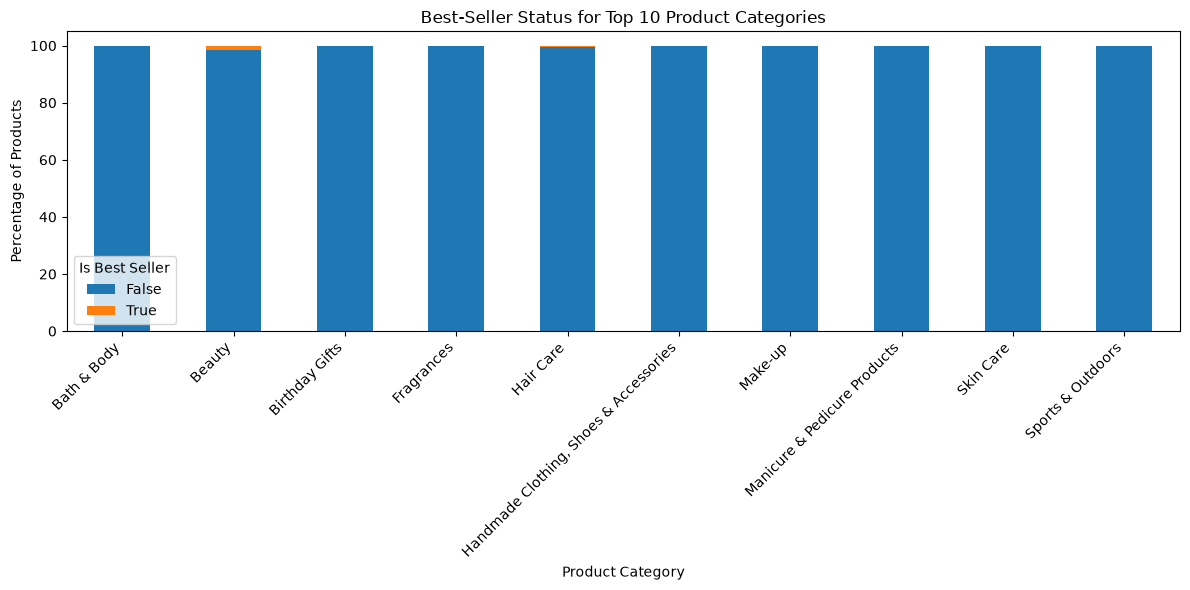

In [43]:
top_10_categories = df["category"].value_counts().head(10).index

top_10_data = df[df["category"].isin(top_10_categories)]

stacked_data = pd.crosstab(
    top_10_data["category"],
    top_10_data["isBestSeller"],
    normalize="index"
) * 100

stacked_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Best-Seller Status for Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Percentage of Products")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Is Best Seller")
plt.tight_layout()
plt.show()

### Stacked Bar Chart Interpretation

Across the top 10 product categories by number of listings, the vast majority of products are not best-sellers.

Best-seller products make up only a small proportion of each category, although the proportion varies slightly between categories. This supports the earlier finding that product category is associated with best-seller status, but the relationship is relatively weak.

In [44]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 9.99
Q3: 45.99
IQR: 36.0
Lower bound: -44.01
Upper bound: 99.99000000000001


In [45]:
df_no_outliers = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

In [46]:
print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_no_outliers))
print("Rows removed:", len(df) - len(df_no_outliers))

print("Original max price:", df["price"].max())
print("Filtered max price:", df_no_outliers["price"].max())

Original rows: 2443651
Rows after removing outliers: 2115963
Rows removed: 327688
Original max price: 100000.0
Filtered max price: 99.99


In [47]:
top_20_categories = df_no_outliers["category"].value_counts().head(20).index

top_20_data = df_no_outliers[
    df_no_outliers["category"].isin(top_20_categories)
]

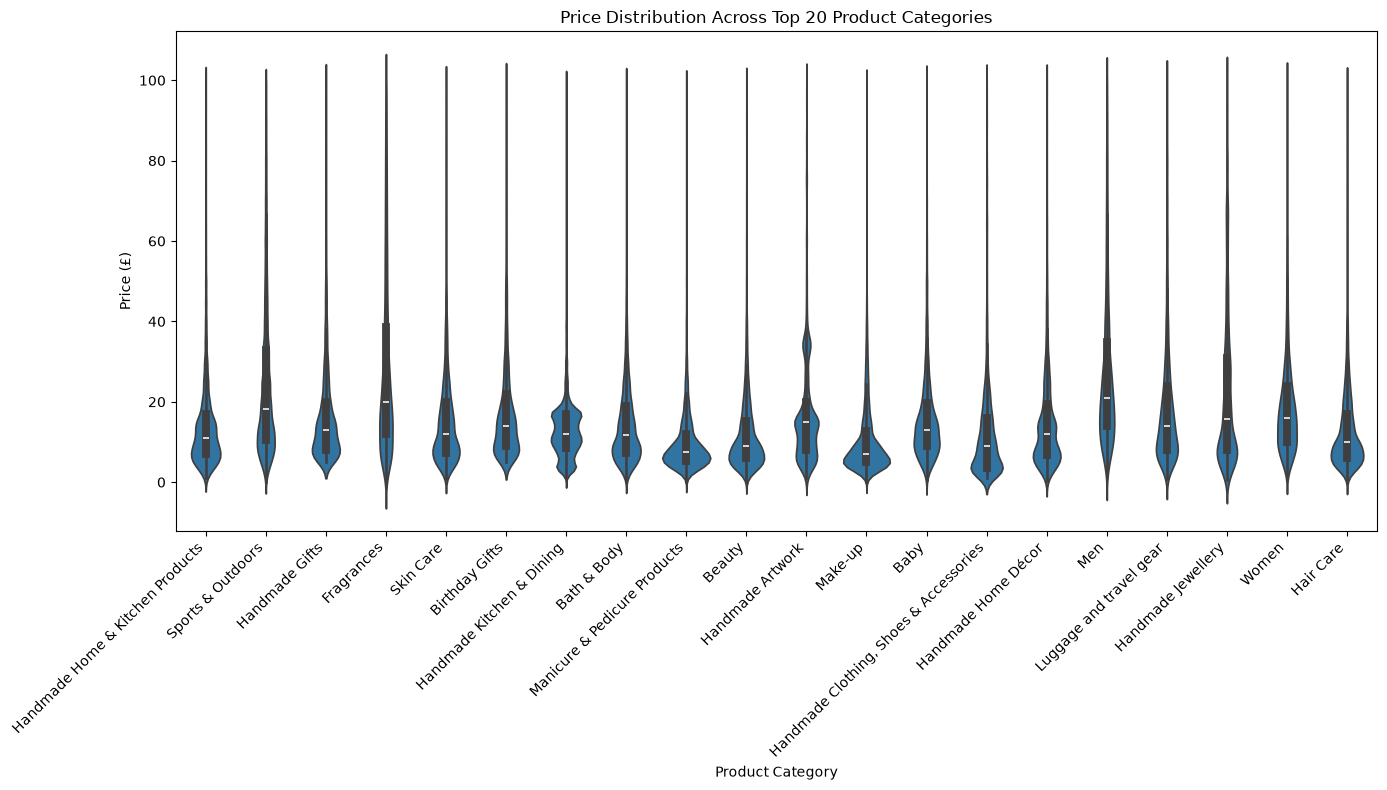

In [48]:
plt.figure(figsize=(14, 8))

sns.violinplot(
    data=top_20_data,
    x="category",
    y="price"
)

plt.title("Price Distribution Across Top 20 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Price (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [49]:
median_price_by_category = (
    df_no_outliers.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

median_price_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

### Violin Plot Interpretation

Price distributions vary across the top 20 product categories.

Most categories have the greatest concentration of products at the lower end of the price range, generally below £20–£30, with thinner tails extending towards the £99.99 outlier threshold.

Some categories, such as **Men**, **Fragrances**, and **Sports & Outdoors**, appear to have higher typical prices than categories such as **Make-up** and **Handmade Clothing, Shoes & Accessories**.

Overall, the shapes show that both the typical price and the spread of prices differ between product categories.

In [50]:
top_10_categories = df_no_outliers["category"].value_counts().head(10).index

In [51]:
average_price_top10 = (
    df_no_outliers[df_no_outliers["category"].isin(top_10_categories)]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_top10

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

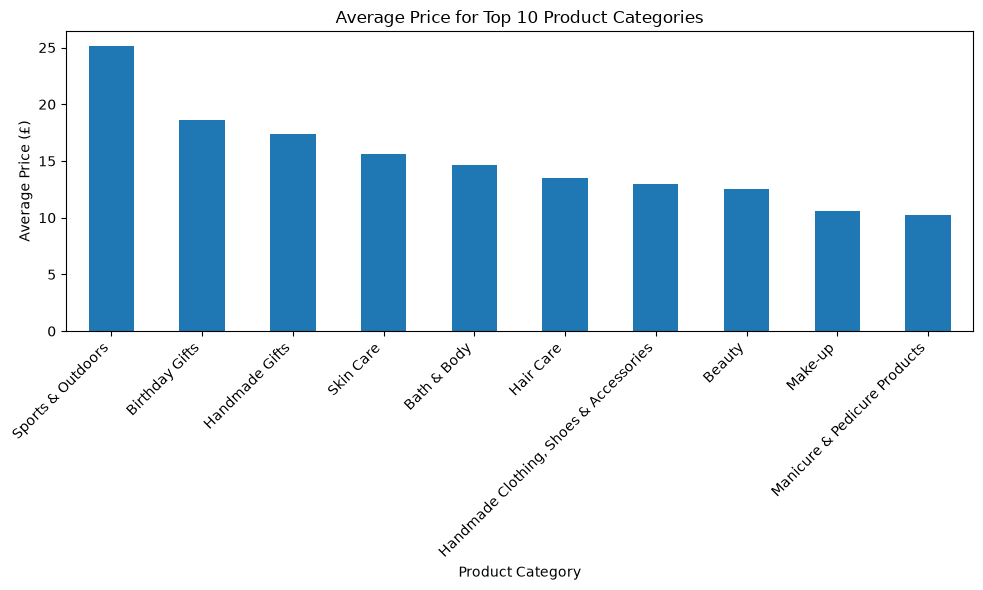

In [52]:
plt.figure(figsize=(10, 6))

average_price_top10.plot(
    kind="bar"
)

plt.title("Average Price for Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [53]:
average_price_by_category = (
    df_no_outliers.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_category.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

### Average Price by Category - Interpretation

Among the top 10 product categories by number of listings, **Sports & Outdoors** has the highest average price at approximately **£25**.

When all product categories are considered, **Motherboards** have the highest average price at approximately **£68.77**, followed by **Boxing Shoes** (£67.42) and **Desktop PCs** (£66.92).

This shows that the categories with the largest number of listings are not necessarily the categories with the highest average product prices.

In [54]:
rated_data = df_no_outliers[df_no_outliers["stars"] > 0]

top_10_rated_categories = (
    rated_data["category"]
    .value_counts()
    .head(10)
    .index
)

rating_plot_data = rated_data[
    rated_data["category"].isin(top_10_rated_categories)
]

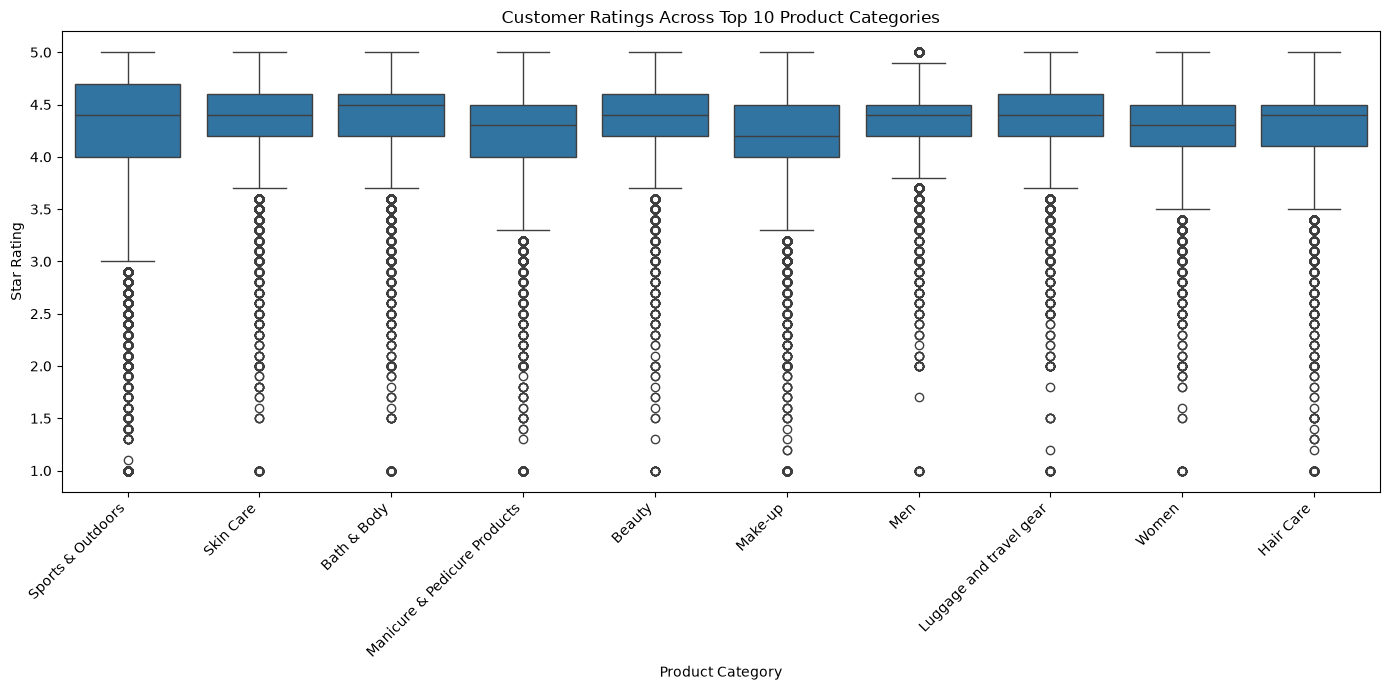

In [55]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=rating_plot_data,
    x="category",
    y="stars"
)

plt.title("Customer Ratings Across Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Ratings by Category - Interpretation

Customer ratings are generally high across the top 10 product categories, with median ratings clustered around roughly **4.2 to 4.5 stars**.

Most categories have a fairly narrow central spread, although there are numerous lower-rating outliers below the main distribution.

Overall, the differences in typical ratings between these high-volume categories appear relatively small.

In [56]:
median_rating_by_category = (
    rated_data.groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

median_rating_by_category.head(10)

category
Handmade Artwork                          5.0
Made in Italy Handmade                    5.0
Handmade Baby Products                    5.0
Handmade Clothing, Shoes & Accessories    4.9
Handmade Kitchen & Dining                 4.9
Birthday Gifts                            4.8
Handmade Home Décor                       4.8
Handmade Gifts                            4.8
Handmade Home & Kitchen Products          4.7
Computer Memory                           4.7
Name: stars, dtype: float64

### Highest Median Rating by Category

The highest median customer rating is **5.0 stars**, shared by **Handmade Artwork**, **Made in Italy Handmade**, and **Handmade Baby Products**.

Several other handmade categories also rank highly, suggesting that handmade product categories tend to receive particularly strong customer ratings.

In [57]:
correlation = df_no_outliers["price"].corr(df_no_outliers["stars"])

print("Correlation:", correlation)

Correlation: -0.0776729987818137


In [58]:
rated_no_outliers = df_no_outliers[df_no_outliers["stars"] > 0]

correlation = rated_no_outliers["price"].corr(rated_no_outliers["stars"])

print("Correlation:", correlation)

Correlation: 0.00674450806715802


### Price and Rating Correlation

After excluding unrated products (`stars == 0`), the correlation between product price and customer rating is approximately **0.007**.

This value is extremely close to zero, indicating **no meaningful linear relationship** between price and star rating.

In this dataset, higher-priced products do not consistently receive higher or lower customer ratings.

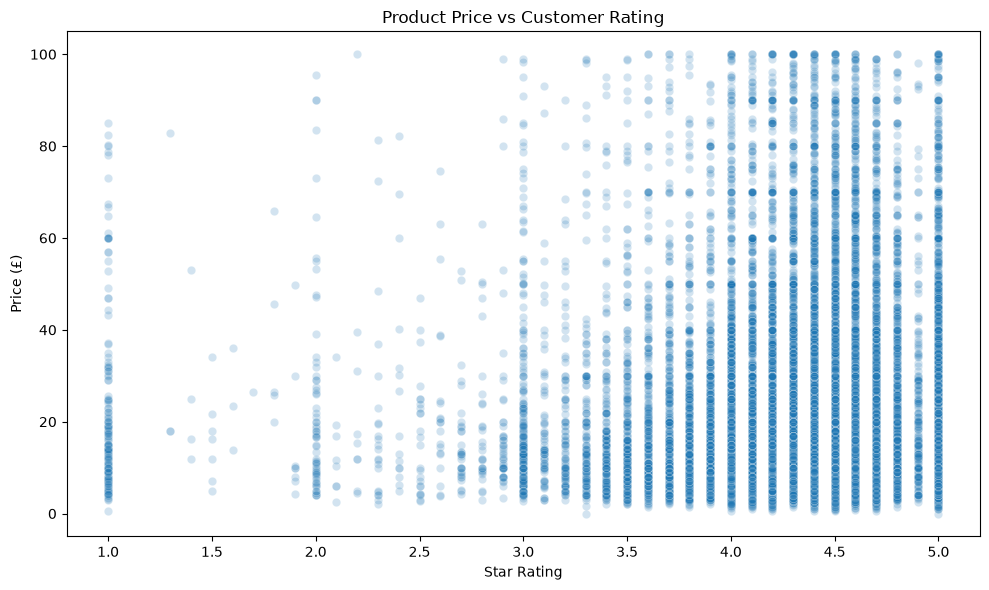

In [59]:
scatter_sample = rated_no_outliers.sample(
    n=20000,
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="stars",
    y="price",
    alpha=0.2
)

plt.title("Product Price vs Customer Rating")
plt.xlabel("Star Rating")
plt.ylabel("Price (£)")
plt.tight_layout()

plt.show()

### Scatter Plot Interpretation

The scatter plot shows no clear relationship between product price and customer rating.

Products with high and low prices appear across almost the full range of star ratings, and there is no obvious upward or downward trend. This supports the correlation coefficient of approximately **0.007**, which indicates essentially no linear relationship between price and rating.

The vertical bands occur because star ratings take discrete values rather than varying continuously.

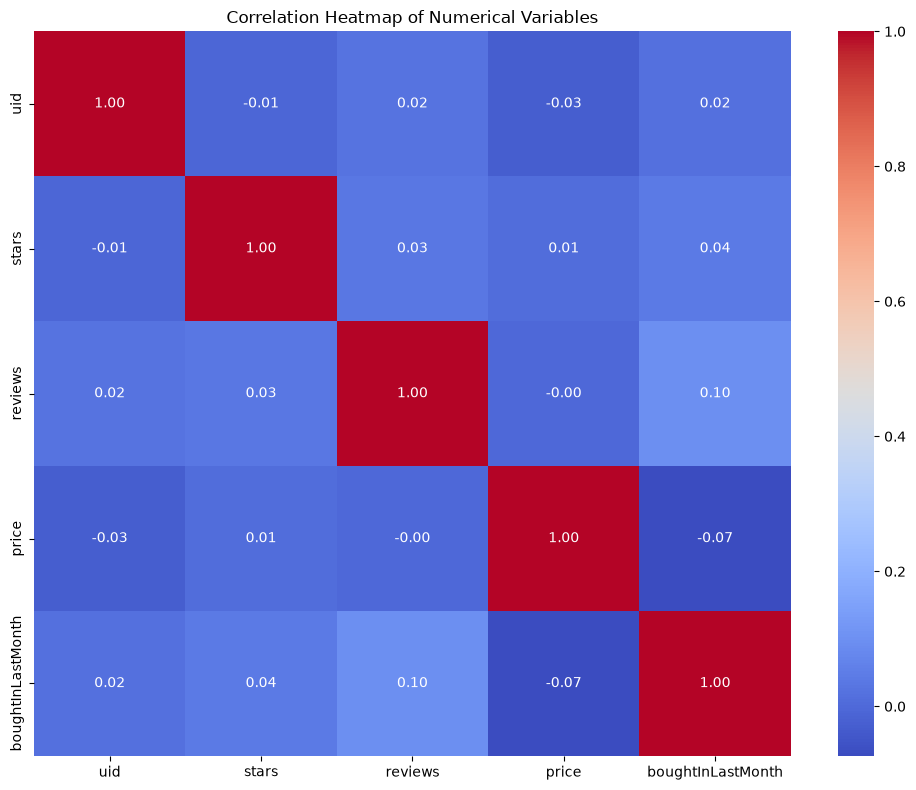

In [60]:
numerical_data = rated_no_outliers.select_dtypes(include="number")

correlation_matrix = numerical_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()

plt.show()

### Correlation Heatmap Interpretation

The heatmap shows that correlations between the numerical variables are generally very weak.

- The correlation between **price and stars** is approximately **0.01**, confirming that product price and customer rating have almost no linear relationship.
- The strongest visible relationship is between **reviews** and **boughtInLastMonth**, at approximately **0.10**, which is still only a very weak positive correlation.
- **Price** and **boughtInLastMonth** show a weak negative correlation of approximately **-0.07**.

Overall, none of the numerical variables show a strong linear relationship with one another in this dataset.

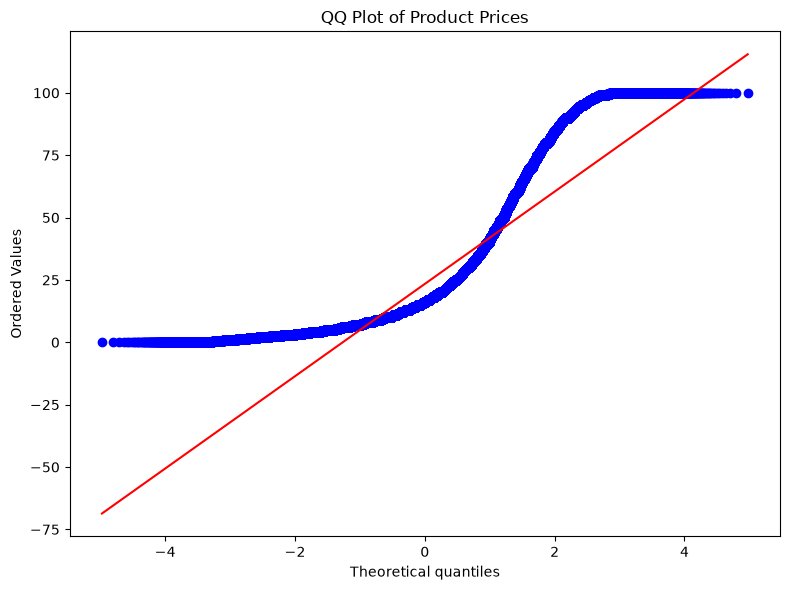

In [61]:
from scipy import stats

plt.figure(figsize=(8, 6))

stats.probplot(
    df_no_outliers["price"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Product Prices")
plt.tight_layout()

plt.show()

### QQ Plot Interpretation

The QQ plot shows that product prices do **not** follow a normal distribution.

The observed values deviate substantially from the theoretical straight line, particularly in the lower and upper tails.

The curved pattern indicates that the price distribution is skewed rather than normally distributed. Even after removing the extreme price outliers, product prices remain concentrated at the lower end with a longer spread towards higher prices.

Therefore, the assumption of normality is not appropriate for product prices in this dataset.

### Final Business Conclusion

Customer ratings are generally high, but there are some category-level differences. **Handmade Artwork, Made in Italy Handmade, and Handmade Baby Products** achieved the highest median rating of **5.0 stars**.

Product price does not appear to influence customer satisfaction: after excluding unrated products, the correlation between **price and star rating is approximately 0.007**, indicating virtually no linear relationship. The wider correlation heatmap also shows that relationships between the numerical variables are generally very weak.

The QQ plot confirms that product prices are **not normally distributed**, even after extreme price outliers were removed. Prices remain concentrated at the lower end with a longer spread towards higher values.

From a business perspective, **higher prices should not be assumed to generate higher customer ratings**. Product category and other product characteristics are likely to be more useful when analysing customer behaviour, while price analysis should account for its strongly non-normal distribution rather than relying only on averages or methods that assume normality.